# Informative Missingness, Firm Risk, and Zombie Firms

Modernized Python/Colab replica of the **Learning and Firm Survival** material and the R code in the `Zombie/Codice` folder.

The notebook uses real data exported in **CSV** format (simpler to open and share in class than the original `.dta` files) for two distinct exercises. The data covers four countries (`IT`, `FR`, `PT`, `ES`): each student can set the `COUNTRY` variable in section 2 to work on their assigned country.

1. **failure prediction** on `data_lagged_10_07.dta`, comparing complete-case models with models that exploit missingness;
2. **annual risk profiles** on `data_italy.dta`, with zombie classification based on staying in the top risk decile for at least three consecutive years.

The main changes relative to the original R code are: stratified cross-validation, metrics suited to rare classes, out-of-fold probabilities to limit overfitting, and explicit leakage handling. XGBoost replaces BART-MIA as the main model because it handles `NaN`s natively and is much simpler to run in Colab. An exact replication of BART-MIA would require a separate R/Java runtime.

## Why zombie firms matter

Since the global financial crisis -- and again after Covid -- many countries have struggled with economic recovery despite unprecedented central-bank and government stimulus. A major obstacle to recovery is **zombie firms**: persistently distressed firms kept alive (often through continued bank credit) well past the point where a healthy market would have let them fail or restructure. This matters because zombie firms:

- can trap banks in **zombie lending**, cutting credit to more viable projects to avoid disclosing non-performing loans (Caballero et al., 2008; Schivardi et al., 2020, 2022 on the crowding-out of resources from healthy firms);
- **drag down aggregate productivity** by keeping unproductive capital and labor in place (McGowan et al., 2018);
- **deter entry** of more productive competitors, weakening competitive pressure on incumbents.

### This notebook's contribution

The underlying study derives firms' failure risk from disclosed financial information *and* from the pattern of their non-random missing values, for firms active in Italy (and, in this teaching version, France, Portugal, and Spain) from 2008 onward. A firm is classified as a **zombie** when its predicted risk stays above a high threshold for at least three consecutive years. The key methodological point -- explored throughout this notebook -- is that *how* a firm's financial disclosures are missing is itself informative about its risk of failure, so a model that uses missingness as a feature (rather than discarding incomplete rows) does substantially better than standard proxy models (Z-scores, Distance-to-Default) or complete-case econometrics.


## How this lesson is organized

The notebook follows one storyline in thirteen steps. Skimming this before running anything gives you a map of where each result feeds into the next.

1. **Setup** (secs 1-2): install packages, mount the data, and pick a `COUNTRY`.
2. **Predictors** (sec 3): what each variable means and how the wide/lagged files are named.
3. **Load the cross-sectional data** (sec 4): one row per firm, its eventual failure outcome.
4. **Missingness** (sec 5): the methodological core of the lesson -- show that values are *not* missing at random, that dropping incomplete rows is costly, and that missingness has structure. Everything after this section exists to answer "so what do we do about it?".
5. **Model horse race** (sec 6): hold the final XGBoost classifier fixed and compare three treatments of missing numeric values -- native XGBoost handling, median imputation, and XGBoost-based imputation.
6. **Interpretation with SHAP** (sec 7): open up the winning model to see which predictors drive its predictions, and in which direction.
7. **Annual predictions** (sec 8): switch from "will this firm ever fail?" to the harder "will it fail *next year*?", one model per year.
8. **Defining zombie firms** (sec 9): turn yearly risk scores into a firm-level label based on three-year persistence in the top risk decile.
9. **Who are the zombies?** (sec 10): productivity, size, and regional patterns among the firms just labeled.
10. **Robustness checklist** (sec 11) and **exporting results** (sec 12): what to change before trusting these numbers, and how to save them.
11. **Homework** (sec 13): test whether a model trained on some countries generalizes to one it has never seen.


## 1. Colab environment


In [1]:
%pip install -q xgboost shap pyarrow openpyxl

In [2]:
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, recall_score, precision_recall_curve,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)


## 2. Configuration

The notebook assumes the same structure used on the local machine: `Zombie/Dati_CSV`. In Colab, upload or sync the `Dati_CSV` folder (no longer `Dati`, which held the original `.dta` files).

Set `COUNTRY` to one of `"IT"`, `"FR"`, `"PT"`, `"ES"` to choose which country to work on: the lagged file already contains all four countries (filtered automatically), while for the annual exercise the corresponding `data_wide_{COUNTRY}.csv` file is loaded.

N.B. For `IT` the wide file is the curated sample used in the paper (168,919 firms); for `FR`, `PT`, `ES` it comes from the raw multi-country panel and has higher missingness — the missing-aware model still handles it natively, but the absolute results are not directly comparable to the historical benchmark (which is computed on IT).

`QUICK_MODE=True` uses a stratified sample to quickly check that the whole pipeline works. Set it to `False` for final estimates. `YEARLY_OOF_FOLDS` controls the cost of building the annual risk profiles: 2 is fine for a first test, 5 for final analyses.


In [3]:
USE_GOOGLE_DRIVE = True  # set False only for local runs outside Colab
DATA_DIR = Path("/content/drive/MyDrive/Zombie/Dati_CSV")

COUNTRY = "IT"  # choose among "IT", "FR", "PT", "ES" -- everything below adapts automatically
country_tag = COUNTRY.lower()

LAGGED_FILE = DATA_DIR / "data_lagged_10_07.csv"   # cross-sectional file, all 4 countries together
WIDE_FILE = DATA_DIR / f"data_wide_{COUNTRY}.csv"  # one file per country (loaded dynamically)
OUTPUT_DIR = Path("/content/zombie_outputs")

YEARS = list(range(2008, 2017))

# QUICK_MODE trades accuracy for speed: smaller sample, fewer folds/trees/CV splits.
# Use it to check that the whole notebook runs end-to-end before committing to a full run.
QUICK_MODE = True
QUICK_MAX_ROWS = 120_000
HORSE_RACE_FOLDS = 3 if QUICK_MODE else 5
YEARLY_OOF_FOLDS = 2 if QUICK_MODE else 5
N_ESTIMATORS = 180 if QUICK_MODE else 500
SHAP_SAMPLE = 2_000

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for path in [LAGGED_FILE, WIDE_FILE]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")


Mounted at /content/drive


## 3. Predictor dictionary

The names follow `ml_analysis_lagged.R` and `country_year_italy.R` directly. Identifier and status variables do not enter the models. The annual prediction exercise uses only year-`t` variables to predict `failure_(t+1)`.


In [4]:
# STATIC_LAGGED: identifier/status columns kept for bookkeeping, never fed to a model.
STATIC_LAGGED = [
    "id", "iso", "region", "time", "failure", "nace_2",
    "Number_of_patents", "Number_of_trademarks", "consdummy", "control"
]

# NUMERIC_LAGGED: the actual predictors for the cross-sectional ("horse race") exercise.
NUMERIC_LAGGED = [
    "Number_of_patents", "Number_of_trademarks", "consdummy",
    "tfp_acf", "fin_rev", "int_paid", "ebitda", "cash_flow", "depr",
    "revenue", "total_assets", "long_term_debt", "employees", "added_value",
    "materials", "wage_bill", "loans", "int_fixed_assets", "fixed_assets",
    "current_liabilities", "liquidity_ratio", "solvency_ratio", "current_assets",
    "fin_expenses", "net_income", "fin_cons100", "inv", "real_SA",
    "shareholders_funds", "NEG_VA", "ICR_failure", "profitability",
    "misallocated_fixed", "interest_diff"
]

# CATEGORICAL_LAGGED: the subset of predictors that need one-hot encoding instead of scaling.
CATEGORICAL_LAGGED = [
    "iso", "nace_2", "control"
]

# YEARLY_BASES: same financial concepts as NUMERIC_LAGGED, but each one exists once per
# calendar year in the wide file (e.g. "ebitda_2008", "ebitda_2009", ...).
YEARLY_BASES = [
    "tfp_acf", "fin_rev", "int_paid", "ebitda", "cash_flow", "depr",
    "revenue", "total_assets", "long_term_debt", "employees", "added_value",
    "materials", "wage_bill", "loans", "int_fixed_assets", "fixed_assets",
    "current_liabilities", "liquidity_ratio", "solvency_ratio", "current_assets",
    "fin_expenses", "net_income", "fin_cons100", "inv", "real_SA",
    "shareholders_funds", "NEG_VA", "ICR_failure", "profitability",
    "misallocated_fixed", "interest_diff"
]

STATIC_WIDE = ["id", "iso", "region", "nace_2", "consdummy", "control", "dummy_patents", "dummy_trademark"]


def year_col(base, year):
    # The original Stata pipeline didn't use one consistent naming convention across
    # variables, so we reproduce its exact quirks here instead of renaming everything
    # (which would risk silently pointing at the wrong column):
    #   - "depr"/"revenue" glue the year directly onto the name (e.g. "revenue2008");
    #   - "misallocated_fixed" puts the year in the middle (e.g. "misallocated_2008_fixed");
    #   - everything else is "base_year" (e.g. "ebitda_2008").
    if base in {"depr", "revenue"}:
        return f"{base}{year}"
    if base == "misallocated_fixed":
        return f"misallocated_{year}_fixed"
    return f"{base}_{year}"


YEARLY_COLUMNS = {year: [year_col(base, year) for base in YEARLY_BASES] for year in YEARS}
# inv_2008 / interest_diff_2008 don't exist: both need a t-1 value, and there is no 2007 data.
YEARLY_COLUMNS[2008] = [c for c in YEARLY_COLUMNS[2008] if c not in {"inv_2008", "interest_diff_2008"}]


### 3.1 Variable glossary

Quick reference for the `NUMERIC_LAGGED` / `YEARLY_BASES` predictors, adapted from the original data dictionary:

| Variable | Meaning |
|---|---|
| `Number_of_patents` / `Number_of_trademarks` | Count of patents / trademarks issued by the firm |
| `consdummy` | 1 if the financial account is consolidated (group-level), 0 if unconsolidated |
| `tfp_acf` | Total factor productivity, estimated a la Ackerberg, Caves & Frazer (2006) |
| `fin_rev` | Financial revenues (EUR) |
| `int_paid` | Interest paid on financial debt (EUR) -- used to compute the ICR |
| `ebitda` | Earnings before interest, taxes, depreciation and amortization (EUR) |
| `cash_flow` | Cash flow (EUR) |
| `depr` | Depreciation and amortization (EUR) |
| `revenue` | Operating revenue / turnover (EUR) |
| `total_assets` | Total assets (EUR) |
| `long_term_debt` | Long-term debt (EUR) |
| `employees` | Number of employees |
| `added_value` | Value added (EUR) |
| `materials` | Cost of materials (EUR) |
| `wage_bill` | Cost of employees / wages (EUR) |
| `loans` | Loans (EUR) |
| `int_fixed_assets` | Intangible fixed assets (EUR) |
| `fixed_assets` | Fixed assets (EUR) |
| `current_liabilities` / `current_assets` | Current liabilities / current assets (EUR) |
| `liquidity_ratio` | Liquidity ratio |
| `solvency_ratio` | Solvency ratio |
| `fin_expenses` | Financial expenses (EUR) |
| `net_income` | Net income (EUR) |
| `fin_cons100` | Financial-constraint indicator a la Nickell & Nicolitsas (1999) |
| `inv` | Investment: depreciation at `t` plus the change in fixed assets between `t-1` and `t` |
| `real_SA` | Hadlock & Pierce (2010) size-age financial-constraint index (larger/older firms score lower, i.e. less constrained) |
| `shareholders_funds` | Shareholders' funds / equity (EUR) |
| `NEG_VA` | 1 if value added is negative (Bank of Korea, 2013) |
| `ICR_failure` | 1 if the interest coverage ratio (EBIT / interest paid) is <= 1 (Bank of England, 2013) |
| `profitability` | Profitability indicator (Schivardi et al., 2017) |
| `misallocated_fixed` | Capital-misallocation indicator on fixed assets (Schivardi et al., 2017) |
| `interest_diff` | Gap between the firm's implicit interest rate and a market benchmark (Caballero et al., 2008) |

Section 3's `YEARLY_BASES` list reuses most of these same concepts, one column per calendar year (e.g. `ebitda_2008`, ..., `ebitda_2016`) rather than one lagged snapshot per firm.


## 4. Loading the lagged analysis

`data_lagged_10_07.csv` contains 450,352 firms across four countries (IT, FR, PT, ES), of which 304,869 are Italian. `time` is the observation duration/time, not the calendar year. This first exercise therefore replicates the cross-sectional horse race from the R code on the country chosen in `COUNTRY`.


In [5]:
lagged_columns = list(dict.fromkeys(STATIC_LAGGED + NUMERIC_LAGGED))
lagged = pd.read_csv(LAGGED_FILE, usecols=lagged_columns, low_memory=False)
lagged = lagged.loc[lagged["iso"].eq(COUNTRY)].copy()   # keep only the selected country
lagged = lagged.dropna(subset=["failure"])              # the outcome must be known to be usable
lagged["failure"] = lagged["failure"].astype(int)

print("Selected country:", COUNTRY)
print("Shape:", lagged.shape)
print("Unique firms:", lagged["id"].nunique())
print("Failure rate:", f"{lagged['failure'].mean():.2%}")
display(lagged.head())


Selected country: IT
Shape: (304869, 41)
Unique firms: 304869
Failure rate: 5.67%


,id,iso,region,time,failure,nace_2,Number_of_patents,Number_of_trademarks,consdummy,control,tfp_acf,fin_rev,int_paid,ebitda,cash_flow,depr,revenue,total_assets,long_term_debt,employees,added_value,materials,wage_bill,loans,int_fixed_assets,fixed_assets,current_liabilities,liquidity_ratio,solvency_ratio,current_assets,fin_expenses,net_income,fin_cons100,inv,real_SA,shareholders_funds,NEG_VA,ICR_failure,profitability,misallocated_fixed,interest_diff
104317,IT00000210054,IT,Piemonte,54.0,0,22.0,0,0,0.0,dom ind,3.827815,0.0,7859.0,8638.0,700.0,610.0,382250.0,428085.0,0.0,6.0,152263.0,177148.0,143625.0,63196.0,0.0,4918.0,167398.0,1.18,24.29,423167.0,7859.0,90.0,90.981710,0.0,-11.405835,103960.0,0.0,0.0,0.0,0.0,0.0
104318,IT00000280263,IT,Veneto,34.0,0,10.0,0,0,0.0,dom ind,NaN,NaN,NaN,NaN,NaN,NaN,250000.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104319,IT00000450155,IT,Lombardia,43.0,0,25.0,0,0,0.0,dom ind,5.991081,50.0,7011.0,110179.0,97420.0,100877.0,1434313.0,1210096.0,0.0,14.0,926298.0,186541.0,816069.0,0.0,40281.0,402248.0,448443.0,1.75,6.66,807848.0,7011.0,-3457.0,6.363282,16882.0,-11.679852,80552.0,0.0,0.0,0.0,0.0,1.0
104320,IT00000520288,IT,Veneto,25.0,1,14.0,0,0,0.0,dom ind,NaN,63.0,5804.0,-634306.0,-640047.0,2648.0,NaN,1321363.0,246089.0,NaN,-595189.0,70563.0,39054.0,75607.0,2237.0,1089913.0,611955.0,0.13,NaN,231450.0,5804.0,-642695.0,-0.915016,-541.0,-11.020110,-596101.0,1.0,1.0,0.0,0.0,0.0
104321,IT00000960526,IT,Toscana,54.0,0,31.0,0,0,0.0,dom ind,NaN,NaN,NaN,NaN,NaN,NaN,250000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
def stratified_cap(data, target, max_rows, seed=42):
    # A plain random sample of a rare-event dataset can end up with very few (or zero)
    # positive cases. Sampling within each class separately, in proportion to its size,
    # keeps the failure rate roughly unchanged while still shrinking the dataset.
    if len(data) <= max_rows:
        return data.copy()
    parts = []
    for value, group in data.groupby(target):
        n = max(1, round(max_rows * len(group) / len(data)))
        parts.append(group.sample(n=n, random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


# Under QUICK_MODE, only the horse race (this section) is subsampled; the annual exercise
# in section 8 always uses the full dataset for the chosen country.
analysis_df = stratified_cap(lagged, "failure", QUICK_MAX_ROWS) if QUICK_MODE else lagged.copy()
feature_cols = list(dict.fromkeys(NUMERIC_LAGGED + CATEGORICAL_LAGGED))
numeric_cols = [c for c in NUMERIC_LAGGED if c in analysis_df.columns]
categorical_cols = [c for c in CATEGORICAL_LAGGED if c in analysis_df.columns]

print("Rows modeled:", len(analysis_df))
print("Modeled failure rate:", f"{analysis_df['failure'].mean():.2%}")


Rows modeled: 120000
Modeled failure rate: 5.67%


## 5. Missingness and failure

The chi-square test indicates association, not causation. With a large sample it is also important to read the difference in missing rates between failed and active firms.

Missing values are usually blamed on human error, respondents' refusal to answer, drop-out, or merging unrelated data sources -- but *why* a value is missing matters a lot for what you can safely do about it. There are three canonical patterns (Little & Rubin, 2019):

- **Missing completely at random (MCAR)**: missingness is unrelated to anything, observed or not. Complete-case analysis is unbiased here -- but this case is rare in practice.
- **Missing at random (MAR)**: missingness is fully explained by *other observed* variables (e.g. small firms are less likely to report financials, but conditional on size this has nothing to do with survival).
- **Missing not at random (MNAR)**: the missingness is related to the very value that's missing (e.g. firms in distress are less likely to disclose the accounts that would reveal it).

MNAR is common in firm-level financial data, and the complete-case approach still popular in economics (surveys suggest roughly 95% of applied papers use it, versus under 5% using imputation) can therefore produce biased estimates rather than just a smaller sample.


,variable,missing_nonfailure,missing_failure,difference_pp,chi2,p_value
9,employees,17.8%,57.7%,+40.0,16259.6,0
6,revenue,6.4%,26.3%,+19.9,9220.3,0
0,tfp_acf,64.7%,62.3%,-2.4,39.5,3.4e-10
18,solvency_ratio,60.5%,56.9%,-3.6,88.5,5.2e-21
10,added_value,65.9%,61.3%,-4.6,151.9,6.7e-35
12,wage_bill,63.5%,54.2%,-9.3,598.2,4.2e-132
22,fin_cons100,63.2%,51.4%,-11.7,958.8,1.6e-210
27,ICR_failure,63.2%,51.4%,-11.8,960.5,7e-211
28,profitability,63.2%,51.4%,-11.8,961.4,4.3e-211
23,inv,63.2%,50.4%,-12.8,1146.7,2.4e-251


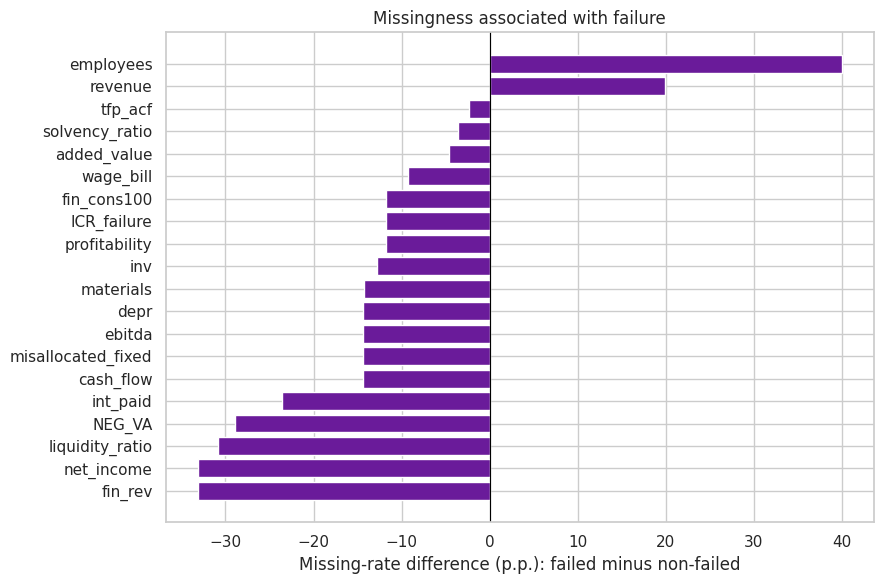

In [7]:
def missingness_association(data, features, target):
    # For each predictor, compare its missing rate between failed and non-failed firms.
    # A 2x2 table of {missing, not missing} x {failure, no failure} feeds a chi-square
    # test: a small p-value means the two are statistically associated (not necessarily causal).
    out = []
    for col in features:
        missing = data[col].isna().astype(int)
        table = pd.crosstab(missing, data[target])
        if missing.nunique() < 2 or table.shape != (2, 2):
            continue  # skip columns with no missing values or no variation in the target
        chi2, p_value, _, _ = chi2_contingency(table)
        m0 = data.loc[data[target] == 0, col].isna().mean()
        m1 = data.loc[data[target] == 1, col].isna().mean()
        out.append({
            "variable": col, "missing_nonfailure": m0, "missing_failure": m1,
            "difference_pp": 100 * (m1 - m0), "chi2": chi2, "p_value": p_value
        })
    return pd.DataFrame(out).sort_values("difference_pp", ascending=False)


missing_table = missingness_association(lagged, feature_cols, "failure")
display(missing_table.head(25).style.format({
    "missing_nonfailure": "{:.1%}", "missing_failure": "{:.1%}",
    "difference_pp": "{:+.1f}", "chi2": "{:.1f}", "p_value": "{:.2g}"
}))

plot_data = missing_table.head(20).sort_values("difference_pp")
plt.figure(figsize=(9, 6))
plt.barh(plot_data["variable"], plot_data["difference_pp"], color="#6A1B9A")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Missing-rate difference (p.p.): failed minus non-failed")
plt.title("Missingness associated with failure")
plt.tight_layout()
plt.show()


### 5.1 How much does it cost to drop incomplete rows?

A complete-case approach would only use firms with **no** missing values among the predictors. How many observations would be lost, and does it vary across countries?

### 5.2 Missingness has structure, it isn't random

If values are missing "in groups" of correlated variables (e.g. the whole financial-statement block together) rather than independently, that is a clue that missingness isn't random (MCAR) but tied to how/when the firm stopped reporting data — consistent with the missingness-failure association seen in section 5.


In [8]:
# "Complete" = a firm has a value for every predictor used by the models below.
# We compute this across ALL FOUR countries (not just the selected one) to make the
# cost of complete-case filtering comparable across the whole dataset.
lagged_all_countries = pd.read_csv(LAGGED_FILE, usecols=list(dict.fromkeys(["iso"] + feature_cols)), low_memory=False)
completeness = lagged_all_countries.assign(
    complete=lagged_all_countries[feature_cols].notna().all(axis=1)
).groupby("iso").agg(firms=("complete", "size"), complete_case=("complete", "sum"))
completeness["complete_case_share"] = completeness["complete_case"] / completeness["firms"]
display(completeness.style.format({"complete_case_share": "{:.1%}"}))
del lagged_all_countries  # free memory, we don't need the other countries' rows anymore


,firms,complete_case,complete_case_share
iso,,,
ES,29531,12327,41.7%
FR,74786,11918,15.9%
IT,304869,90735,29.8%
PT,41166,16717,40.6%


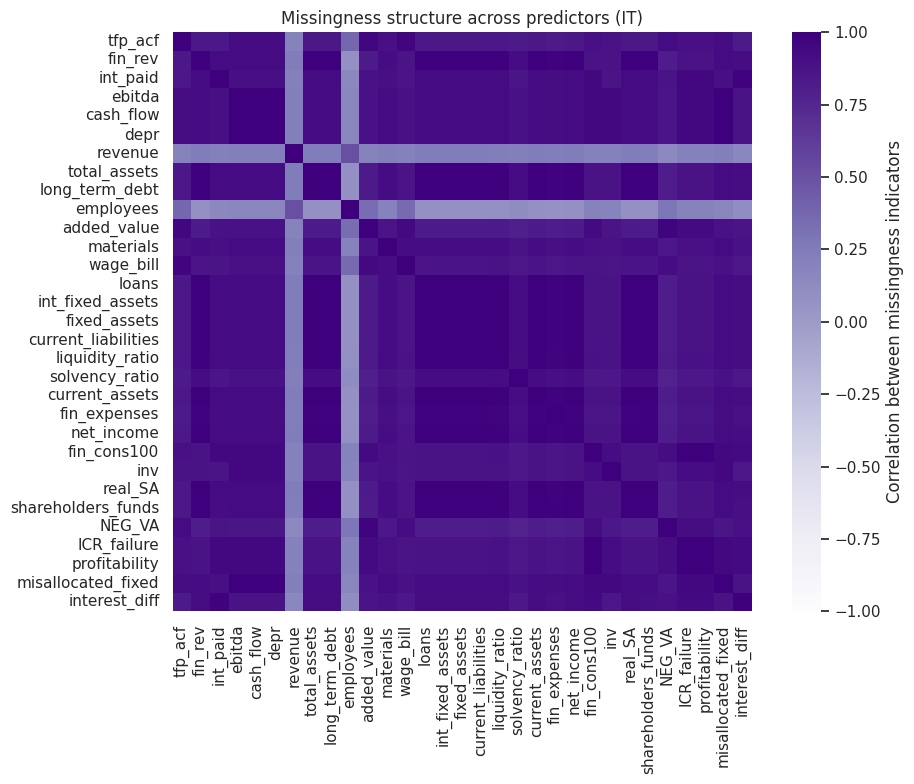

In [9]:
# Turn each predictor into a 0/1 "is this value missing?" indicator, then correlate
# those indicators with each other. High correlation between two indicators means the
# two variables tend to be missing together -- a sign of structured, non-random missingness.
missing_indicators = lagged[feature_cols].isna().astype(int)
missing_corr = missing_indicators.loc[:, missing_indicators.nunique() > 1].corr()  # drop columns with no missingness at all

plt.figure(figsize=(10, 8))
sns.heatmap(missing_corr, cmap="Purples", vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Correlation between missingness indicators"})
plt.title(f"Missingness structure across predictors ({COUNTRY})")
plt.tight_layout()
plt.show()


### 5.3 What the original study found

For context, in the original Italian sample: about 19% of firms have an interest coverage ratio (ICR) below one (a classic distress signal), but 62.5% of firms have *no* ICR information at all -- missingness dwarfs the signal you'd get from the ratio alone. The slides describe this in aggregate terms: comparing 287,787 non-failing firms against 4,718 failed/dissolved firms, chi-square tests confirm that missing shares differ systematically by failure status, which the original presentation summarizes as "firms disclose relatively less when they are in trouble."

### 5.4 But which direction, variable by variable?

Run `missing_table.sort_values("diff_pp")` yourself and the picture is more interesting than that one-line summary suggests. On the IT sample, almost every detailed balance-sheet item (`total_assets`, `shareholders_funds`, `long_term_debt`, `interest_diff`, `liquidity_ratio`, `int_paid`, ...) is *less* missing among firms that eventually fail -- by 10 to 40 percentage points -- while `revenue` and especially `employees` are *more* missing among failed firms (+20pp and +40pp respectively). A plausible mechanism: formal insolvency/liquidation procedures in Italy typically require filing a complete, audited balance sheet, so a firm heading into failure can end up with *more* granular accounting detail on record than an ordinary small firm that only ever files a simplified statement. Revenue and headcount, by contrast, are the basic "is this business still running" figures that stop being reported once activity actually winds down -- which does match the naive story.

The lesson isn't "the slides were wrong" -- it's that a single aggregate statistic ("missingness is associated with failure") can hide opposite-signed relationships at the variable level, and different data-generating mechanisms (accounting-detail disclosure vs. operational reporting) can point in opposite directions within the *same* dataset. This is exactly why the missing-aware XGBoost model is left to learn a separate relationship for each feature rather than being told a single direction in advance -- and why you should check this table for whichever `COUNTRY` you're working on rather than assuming it transfers.


## 6. Model horse race

To isolate the effect of the **missing-value treatment**, all three models below use the **same XGBoost classifier** and the same cross-validation folds. Only the numeric preprocessing changes:

1. **Base XGBoost**: leave numeric `NaN`s untouched and let XGBoost route missing observations natively;
2. **Median imputation**: replace missing numeric values with the training-fold median and add missingness indicators;
3. **XGBoost imputation**: use an `IterativeImputer` whose prediction model is `XGBRegressor`, again with missingness indicators.

Categorical preprocessing is held fixed across all three cases. Because the imputation steps live inside the scikit-learn `Pipeline`, every imputer is fit only on each training fold, avoiding validation-fold leakage.

Probabilities are out-of-fold. **PR AUC** is the main comparison metric because failure is rare; ROC AUC, precision, recall, specificity, F1, and balanced accuracy complete the picture.

### Where these models come from

The exercise focuses on whether explicit imputation improves on XGBoost's native treatment of missing values. XGBoost is a gradient-boosting tree algorithm that can learn a default direction for missing observations at each split. The model-based imputation alternative instead predicts each missing numerical feature from the other numerical features before the final classifier is trained. Keeping the final classifier fixed makes the three cases directly comparable as missing-data strategies.


In [10]:
def dense_ohe():
    # scikit-learn renamed the "sparse" argument to "sparse_output" in newer versions.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def model_factory(num_cols, cat_cols, pos_weight):
    """Three XGBoost classifiers that differ only in numeric missing-value treatment."""

    def final_xgb():
        return XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=pos_weight,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    def cat_preprocessor():
        # Keep categorical treatment identical across all three models.
        return Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", dense_ohe())
        ])

    # 1) BASE: numerical NaNs are passed straight to XGBoost.
    native_pre = ColumnTransformer([
        ("num", "passthrough", num_cols),
        ("cat", cat_preprocessor(), cat_cols),
    ])

    # 2) MEDIAN: fold-specific median imputation + explicit missingness indicators.
    median_pre = ColumnTransformer([
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True))
        ]), num_cols),
        ("cat", cat_preprocessor(), cat_cols),
    ])

    # 3) XGBOOST IMPUTATION: predict missing numerical features from other numerical features.
    xgb_imputer = IterativeImputer(
        estimator=XGBRegressor(
            n_estimators=60 if QUICK_MODE else 150,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        initial_strategy="median",
        max_iter=1 if QUICK_MODE else 3,
        n_nearest_features=10 if QUICK_MODE else None,
        skip_complete=True,
        add_indicator=True,
        random_state=RANDOM_STATE
    )

    xgb_impute_pre = ColumnTransformer([
        ("num", Pipeline([
            ("impute", xgb_imputer)
        ]), num_cols),
        ("cat", cat_preprocessor(), cat_cols),
    ])

    return {
        "Base XGBoost": Pipeline([
            ("pre", native_pre),
            ("model", final_xgb())
        ]),
        "Median imputation": Pipeline([
            ("pre", median_pre),
            ("model", final_xgb())
        ]),
        "XGBoost imputation": Pipeline([
            ("pre", xgb_impute_pre),
            ("model", final_xgb())
        ]),
    }


def best_bacc_threshold(y, p):
    # 0.5 is a poor default cutoff when failures are rare. Search candidate cutoffs
    # and retain the one maximizing balanced accuracy.
    candidates = np.unique(np.quantile(p, np.linspace(0.01, 0.99, 199)))
    scores = [balanced_accuracy_score(y, p >= t) for t in candidates]
    return float(candidates[int(np.argmax(scores))])


def evaluate_probabilities(y, p):
    threshold = best_bacc_threshold(y, p)
    pred = p >= threshold

    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "ROC_AUC": roc_auc_score(y, p),
        "PR_AUC": average_precision_score(y, p),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y, pred, zero_division=0),
        "BACC": balanced_accuracy_score(y, pred),
        "threshold": threshold
    }


In [11]:
X = analysis_df[feature_cols]
y = analysis_df["failure"].to_numpy()
cv = StratifiedKFold(n_splits=HORSE_RACE_FOLDS, shuffle=True, random_state=RANDOM_STATE)
pos_weight = max((y == 0).sum() / max((y == 1).sum(), 1), 1.0)
models = model_factory(numeric_cols, categorical_cols, pos_weight)

oof_predictions = {}
rows = []

for name, model in models.items():
    print(f"Running: {name}")
    start = time.time()

    # Every probability is out-of-fold: the model and its imputer are fit without
    # seeing the observation being predicted.
    p = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    oof_predictions[name] = (y, p)
    result = evaluate_probabilities(y, p)
    result.update({"model": name, "n": len(X), "seconds": time.time() - start})
    rows.append(result)

metrics = pd.DataFrame(rows)[[
    "model", "n", "ROC_AUC", "PR_AUC", "Precision", "Recall",
    "Specificity", "F1", "BACC", "threshold", "seconds"
]]

display(metrics.style.format({
    "ROC_AUC": "{:.4f}",
    "PR_AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "Specificity": "{:.4f}",
    "F1": "{:.4f}",
    "BACC": "{:.4f}",
    "threshold": "{:.4f}",
    "seconds": "{:.1f}"
}))


Running: Base XGBoost
Running: Median imputation
Running: XGBoost imputation


,model,n,ROC_AUC,PR_AUC,Precision,Recall,Specificity,F1,BACC,threshold,seconds
0,Base XGBoost,120000,0.9716,0.7615,0.3261,0.9402,0.8832,0.4843,0.9117,0.4331,12.7
1,Median imputation,120000,0.9707,0.7529,0.3248,0.9362,0.8830,0.4822,0.9096,0.4426,13.5
2,XGBoost imputation,120000,0.9710,0.7549,0.3339,0.9334,0.8881,0.4918,0.9107,0.4612,35.3


### Historical benchmark from the slides

| Analysis | Model | ROC AUC | PR AUC | F1 | BACC |
|---|---|---:|---:|---:|---:|
| Complete-case | Logit | 0.8966 | 0.4542 | 0.1833 | 0.7504 |
| Complete-case | Random Forest | 0.9117 | 0.5233 | 0.1907 | 0.7595 |
| Complete-case | Super Learner | 0.9231 | 0.5464 | 0.1844 | 0.7535 |
| Missing-aware | XGBoost | 0.9685 | 0.7591 | 0.2070 | 0.7646 |
| Missing-aware | BART-MIA | 0.9681 | 0.7516 | 0.2092 | 0.7676 |

Differences from these values can depend on filters, data version, validation scheme, and hyperparameters. They should not automatically be interpreted as errors.

These values are computed on the **Italian** sample (original paper). When selecting a `COUNTRY` other than `"IT"`, the absolute values are not directly comparable to this table.


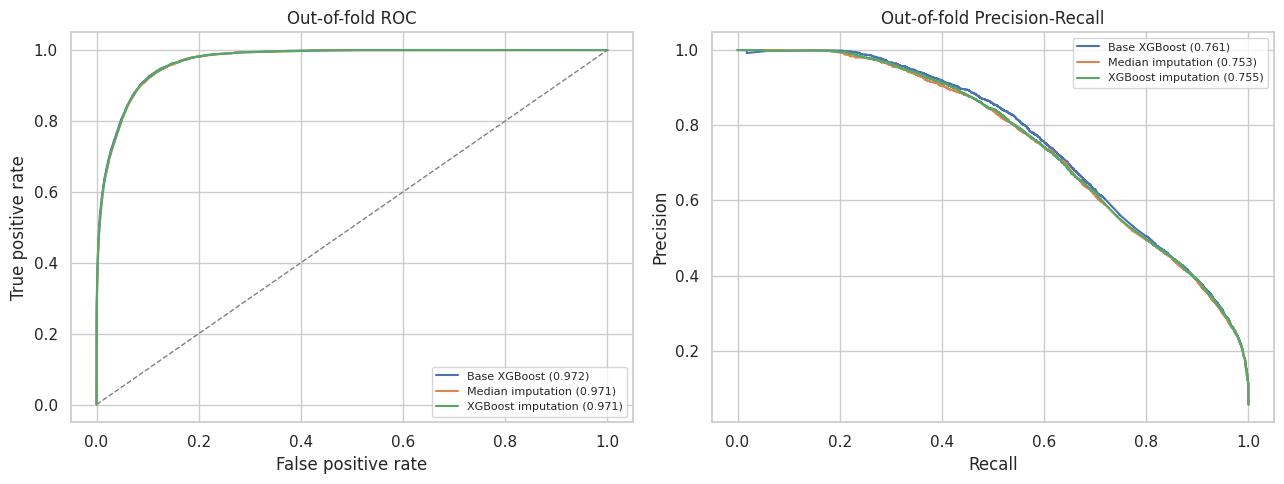

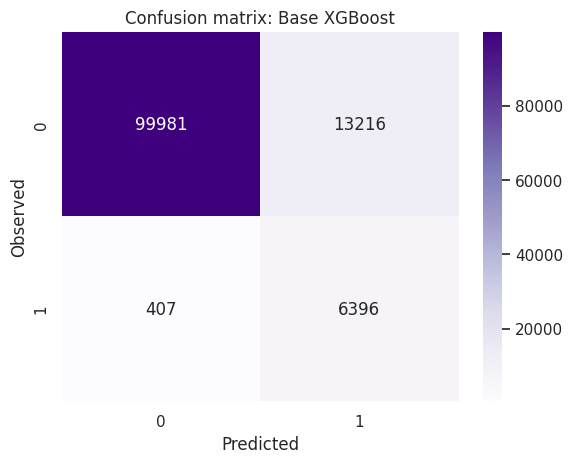

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, (y_used, p) in oof_predictions.items():
    fpr, tpr, _ = roc_curve(y_used, p)
    precision, recall, _ = precision_recall_curve(y_used, p)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_used, p):.3f})")
    axes[1].plot(recall, precision, label=f"{name} ({average_precision_score(y_used, p):.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=1)  # diagonal = random guessing
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title="Out-of-fold ROC")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Out-of-fold Precision-Recall")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Pick the model with the best PR AUC and show its confusion matrix at its own
# balanced-accuracy-optimal threshold (computed in evaluate_probabilities above).
best_name = metrics.sort_values("PR_AUC", ascending=False).iloc[0]["model"]
y_best, p_best = oof_predictions[best_name]
t_best = float(metrics.loc[metrics["model"].eq(best_name), "threshold"].iloc[0])
cm = confusion_matrix(y_best, p_best >= t_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.title(f"Confusion matrix: {best_name}")
plt.show()


## 7. Final model and SHAP

SHAP describes the structure of the predictions and does not identify causal effects. The variable categories follow the presentation's figure.

Formally, if $S$ is a subset of the $q$ predictors, $m$ is one predictor not in $S$, and $v(S)$ is the model's goodness-of-fit using only the predictors in $S$, the **Shapley value** of predictor $m$ is:

$$
\phi_m(v) = \frac{1}{q} \sum_{S \subseteq \{1,\dots,q\}\setminus\{m\}} \big[v(S \cup \{m\}) - v(S)\big]\, \frac{|S|!\,(q-|S|-1)!}{q!}
$$

In words: $\phi_m$ is a weighted average, over *every possible subset of the other predictors*, of how much adding $m$ to that subset improves the model. `shap.TreeExplainer` computes an efficient, exact version of this for tree ensembles like XGBoost, which is what the bar chart and beeswarm plot below visualize per feature (and, in the beeswarm's case, per firm).


Model selected for SHAP: Base XGBoost


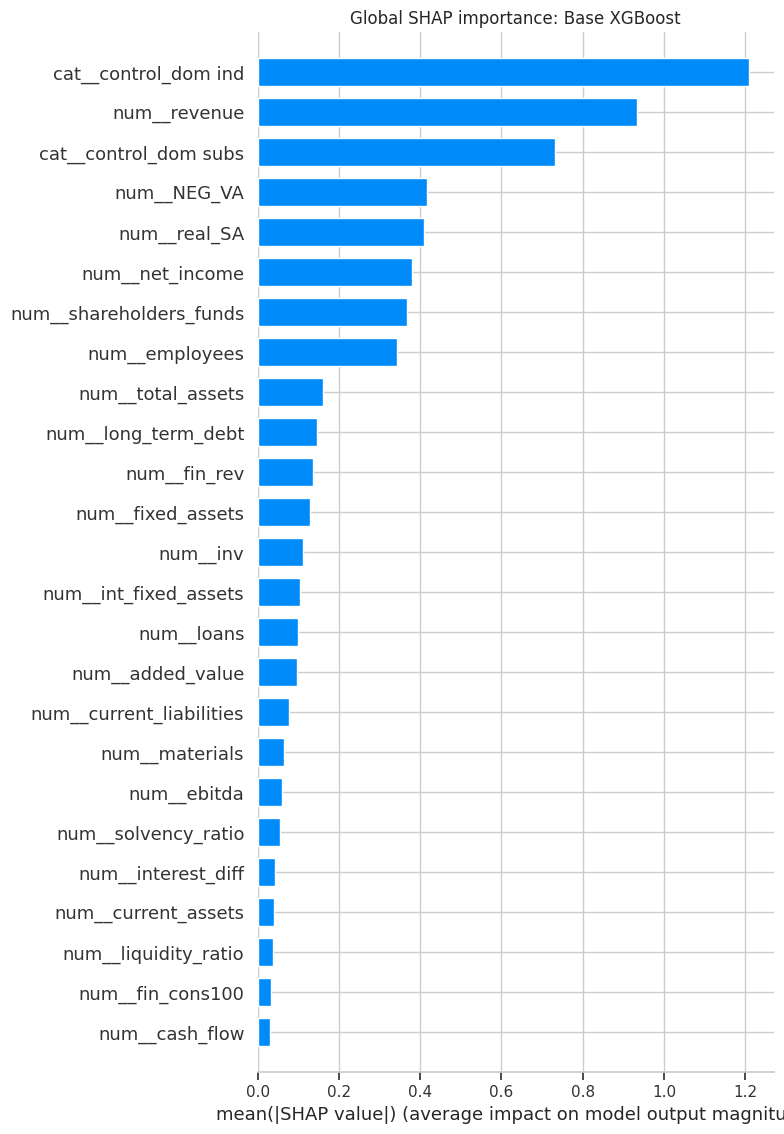

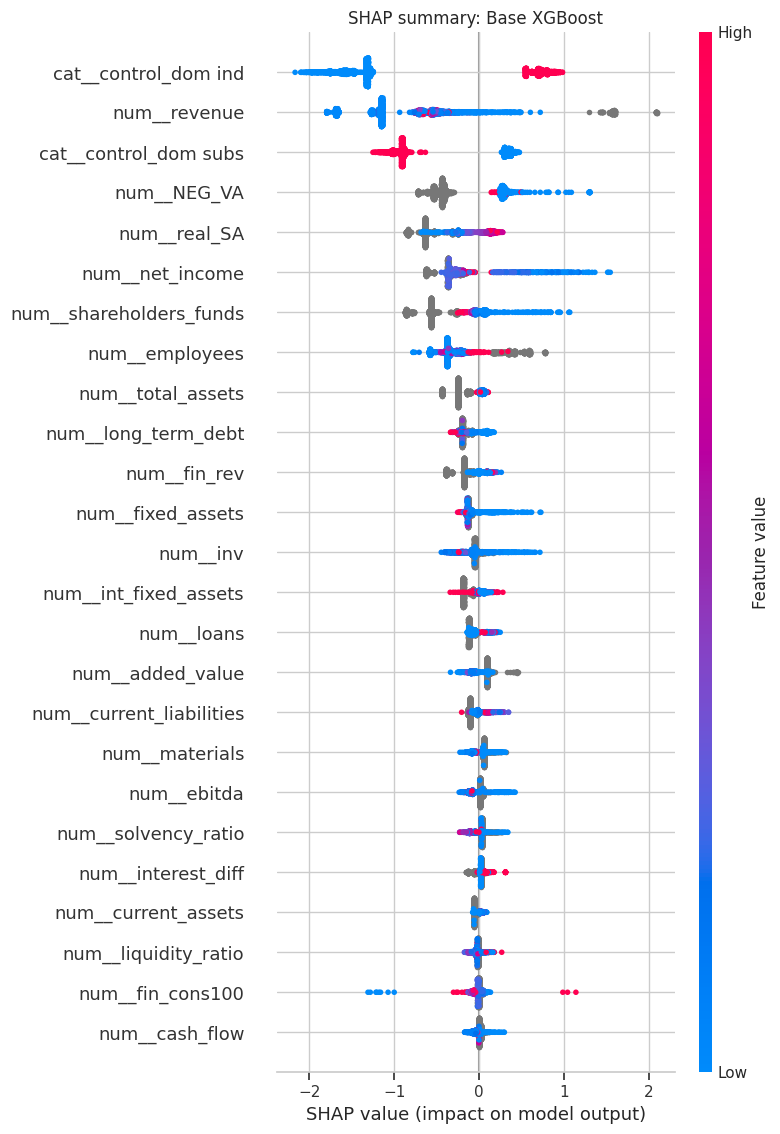

,feature,mean_abs_shap
59,cat__control_dom ind,1.210105
9,num__revenue,0.933807
60,cat__control_dom subs,0.731877
29,num__NEG_VA,0.415704
27,num__real_SA,0.408679
24,num__net_income,0.379149
28,num__shareholders_funds,0.368694
12,num__employees,0.341893
10,num__total_assets,0.162059
11,num__long_term_debt,0.146859


In [13]:
# Choose the best of the three missing-data strategies by out-of-fold PR AUC.
best_model_name = metrics.loc[metrics["PR_AUC"].idxmax(), "model"]
print("Model selected for SHAP:", best_model_name)

# Refit that pipeline on the full analysis sample so SHAP explains one final model.
xgb_model = models[best_model_name]
xgb_model.fit(X, y)

import shap

# SHAP is computed on a random subsample purely for speed.
sample = X.sample(min(SHAP_SAMPLE, len(X)), random_state=RANDOM_STATE)
X_t = xgb_model.named_steps["pre"].transform(sample)
feature_names = xgb_model.named_steps["pre"].get_feature_names_out()
explainer = shap.TreeExplainer(xgb_model.named_steps["model"])
shap_values = explainer.shap_values(X_t)

# Bar chart: global importance = mean absolute SHAP value.
shap.summary_plot(
    shap_values, X_t,
    feature_names=feature_names,
    plot_type="bar",
    max_display=25,
    show=False
)
plt.title(f"Global SHAP importance: {best_model_name}")
plt.tight_layout()
plt.show()

# Beeswarm: direction, magnitude, and heterogeneity of contributions across firms.
shap.summary_plot(
    shap_values, X_t,
    feature_names=feature_names,
    max_display=25,
    show=False
)
plt.title(f"SHAP summary: {best_model_name}")
plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(30))


,group,mean_abs_shap
0,Financial accounts,2.107074
2,Governance,1.942555
4,Other,1.221342
9,Zombie indicators,0.454582
8,Size,0.341893
1,Financial constraints,0.171011
5,Productivity,0.116660
7,Sector,0.059880
6,Profitability,0.011888
3,Innovation,0.003864


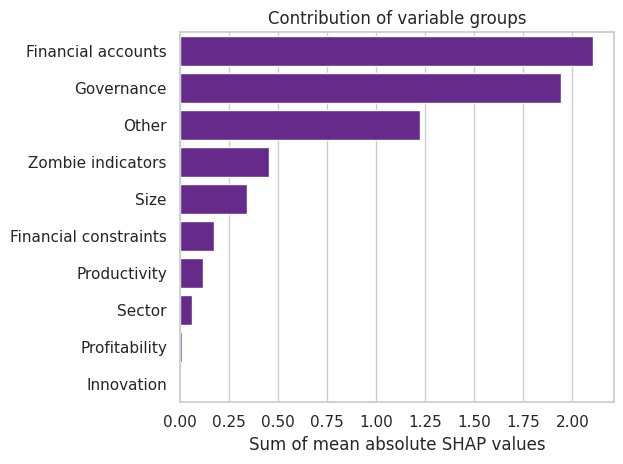

In [14]:
# Individual one-hot-encoded/feature-engineered column names are hard to read at a
# glance (e.g. "num__tfp_acf"), so we roll them up into broader, human-readable groups
# by matching keywords -- purely for presentation, it doesn't change the model.
GROUP_KEYWORDS = {
    "Financial accounts": ["asset", "revenue", "debt", "cash", "ebit", "income", "cost", "wage", "loan"],
    "Governance": ["group", "control", "consolid"],
    "Size": ["employee", "asset", "revenue"],
    "Financial constraints": ["interest", "coverage", "liquid", "leverage", "solvency", "fin_cons"],
    "Missingness": ["missing", "indicator"],
    "Productivity": ["tfp", "productiv", "added_value"],
    "Sector": ["nace", "sector", "industry"],
    "Area": ["region", "nuts", "area"],
    "Profitability": ["profit", "roa", "roe"],
    "Zombie indicators": ["icr_failure", "negative", "neg_va", "misallocated"],
    "Innovation": ["patent", "trademark"]
}


def assign_group(feature):
    f = feature.lower()
    for group, keys in GROUP_KEYWORDS.items():
        if any(key in f for key in keys):
            return group
    return "Other"


group_shap = (
    shap_importance.assign(group=lambda d: d["feature"].map(assign_group))
    .groupby("group", as_index=False)["mean_abs_shap"].sum()
    .sort_values("mean_abs_shap", ascending=False)
)
display(group_shap)
sns.barplot(data=group_shap, y="group", x="mean_abs_shap", color="#6A1B9A")
plt.xlabel("Sum of mean absolute SHAP values")
plt.ylabel("")
plt.title("Contribution of variable groups")
plt.tight_layout()
plt.show()


## 8. Annual data in wide format

The R code trains a separate model for each year, using year-`t` financial statements to predict `failure_(t+1)`. Here probabilities are computed out-of-fold within each year, so every firm gets a prediction from a model that never used it in training.

For the homework comparison, the same three missing-data strategies from section 6 are now carried into the annual exercise: **Base XGBoost**, **Median imputation**, and **XGBoost imputation**. This lets us see whether the preprocessing choice changes not only predictive metrics, but also the resulting zombie-firm prevalence.

The `data_wide_{COUNTRY}.csv` file already contains only the columns needed for the selected country (for `IT` it is the curated sample of 168,919 firms used in the paper; for the other countries it comes from the raw multi-country panel).


In [15]:
wide_columns = list(STATIC_WIDE)
for year in YEARS:
    wide_columns.extend(YEARLY_COLUMNS[year])
    wide_columns.append(f"failure_{year + 1}")
wide_columns = list(dict.fromkeys(wide_columns))

# usecols as a function (rather than a fixed list) tolerates the file having "iso" plus
# whatever subset of wide_columns it actually contains for this country.
wide = pd.read_csv(WIDE_FILE, usecols=lambda c: c in set(wide_columns) or c == "iso", low_memory=False)
wide = wide.loc[wide["iso"].eq(COUNTRY)].copy()
print("Selected country:", COUNTRY)
print("Selected wide shape:", wide.shape)
print("Unique firms:", wide["id"].nunique())


Selected country: IT
Selected wide shape: (168919, 294)
Unique firms: 168919


In [16]:
def yearly_xgb_pipeline(num_cols, cat_cols, pos_weight, strategy="native"):
    """Annual XGBoost pipeline with one of the three numeric missing-data strategies."""

    def cat_preprocessor():
        return Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ohe", dense_ohe())
        ])

    if strategy == "native":
        num_pre = "passthrough"

    elif strategy == "median":
        num_pre = Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True))
        ])

    elif strategy == "xgb_imp":
        # Keep the quick-mode auxiliary models deliberately small: this imputer is nested
        # inside annual cross-validation and is therefore much more expensive than median imputation.
        num_pre = Pipeline([
            ("impute", IterativeImputer(
                estimator=XGBRegressor(
                    n_estimators=40 if QUICK_MODE else 150,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    objective="reg:squarederror",
                    tree_method="hist",
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                ),
                initial_strategy="median",
                max_iter=1 if QUICK_MODE else 3,
                n_nearest_features=8 if QUICK_MODE else None,
                skip_complete=True,
                add_indicator=True,
                random_state=RANDOM_STATE
            ))
        ])

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    pre = ColumnTransformer([
        ("num", num_pre, num_cols),
        ("cat", cat_preprocessor(), cat_cols)
    ])

    return Pipeline([
        ("pre", pre),
        ("model", XGBClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_weight=5,
            reg_lambda=2.0,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=pos_weight,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])


def run_yearly_model(strategy, label):
    """Create out-of-fold annual risk scores for one missing-data strategy."""
    risk_model = wide[["id", "region", "nace_2"]].copy()
    metric_rows = []

    for year in YEARS:
        target = f"failure_{year + 1}"
        current_num = YEARLY_COLUMNS[year] + ["consdummy", "dummy_patents", "dummy_trademark"]
        current_cat = ["nace_2", "control"]
        cols = current_num + current_cat

        valid = wide[target].notna()
        work = wide.loc[valid, cols + [target]].copy()
        y_year = work[target].astype(int).to_numpy()

        if np.unique(y_year).size < 2:
            print(label, year, "skipped: target has a single class")
            continue

        pos_weight_year = max((y_year == 0).sum() / max((y_year == 1).sum(), 1), 1.0)
        model = yearly_xgb_pipeline(
            current_num,
            current_cat,
            pos_weight_year,
            strategy=strategy
        )

        cv_year = StratifiedKFold(
            n_splits=YEARLY_OOF_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE + year
        )

        p_year = cross_val_predict(
            model,
            work[cols],
            y_year,
            cv=cv_year,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        # Store annual out-of-fold failure probabilities.
        risk_model[f"prob_{country_tag}_{year + 1}"] = np.nan
        risk_model.loc[valid, f"prob_{country_tag}_{year + 1}"] = p_year

        # Risk categories: top decile = 1; 8th-9th decile = 2; lower 80% = 0.
        q90 = np.nanquantile(p_year, 0.90)
        q80 = np.nanquantile(p_year, 0.80)
        category = np.where(p_year >= q90, 1, np.where(p_year >= q80, 2, 0))
        risk_model[f"cat_{country_tag}_{year + 1}"] = np.nan
        risk_model.loc[valid, f"cat_{country_tag}_{year + 1}"] = category

        row = evaluate_probabilities(y_year, p_year)
        row.update({
            "model": label,
            "feature_year": year,
            "target_year": year + 1,
            "n": len(y_year),
            "event_rate": y_year.mean()
        })
        metric_rows.append(row)
        print(f"{label}: completed {year} -> {year + 1}, PR AUC={row['PR_AUC']:.3f}")

    return risk_model, pd.DataFrame(metric_rows)


# Run the annual exercise for all three missing-data strategies.
model_specs = [
    ("native", "Base XGBoost"),
    ("median", "Median imputation"),
    ("xgb_imp", "XGBoost imputation")
]

risk_results = {}
yearly_metrics_list = []

for strategy, label in model_specs:
    print("\n" + "=" * 70)
    print("Running annual model:", label)
    print("=" * 70)

    risk_tmp, metrics_tmp = run_yearly_model(strategy, label)
    risk_results[label] = risk_tmp
    yearly_metrics_list.append(metrics_tmp)

yearly_metrics_all = pd.concat(yearly_metrics_list, ignore_index=True)

# Easy annual predictive-performance comparison.
pr_auc_by_year = yearly_metrics_all.pivot(
    index="target_year",
    columns="model",
    values="PR_AUC"
).sort_index()

display(pr_auc_by_year.style.format("{:.3f}"))



Running annual model: Base XGBoost
Base XGBoost: completed 2008 -> 2009, PR AUC=0.041
Base XGBoost: completed 2009 -> 2010, PR AUC=0.051
Base XGBoost: completed 2010 -> 2011, PR AUC=0.055
Base XGBoost: completed 2011 -> 2012, PR AUC=0.052
Base XGBoost: completed 2012 -> 2013, PR AUC=0.067
Base XGBoost: completed 2013 -> 2014, PR AUC=0.054
Base XGBoost: completed 2014 -> 2015, PR AUC=0.165
Base XGBoost: completed 2015 -> 2016, PR AUC=0.171
Base XGBoost: completed 2016 -> 2017, PR AUC=0.437

Running annual model: Median imputation
Median imputation: completed 2008 -> 2009, PR AUC=0.041
Median imputation: completed 2009 -> 2010, PR AUC=0.057
Median imputation: completed 2010 -> 2011, PR AUC=0.062
Median imputation: completed 2011 -> 2012, PR AUC=0.050
Median imputation: completed 2012 -> 2013, PR AUC=0.063
Median imputation: completed 2013 -> 2014, PR AUC=0.056
Median imputation: completed 2014 -> 2015, PR AUC=0.163
Median imputation: completed 2015 -> 2016, PR AUC=0.172
Median imputatio

model,Base XGBoost,Median imputation,XGBoost imputation
target_year,,,
2009,0.041,0.041,0.041
2010,0.051,0.057,0.055
2011,0.055,0.062,0.059
2012,0.052,0.050,0.051
2013,0.067,0.063,0.065
2014,0.054,0.056,0.056
2015,0.165,0.163,0.167
2016,0.171,0.172,0.170
2017,0.437,0.444,0.443


### 8.1 Predicting WHETHER is easier than predicting WHEN

The horse-race PR AUC (section 6, full horizon: will the firm ever fail?) and the annual models' PR AUCs (section 8, one-year horizon: will it fail *next year*?) are not directly comparable, but the comparison is instructive. The annual task is generally harder because failure within a single year is rarer, the timing signal is weaker, and reporting may become especially irregular near failure.


,Horse-race PR AUC,Annual average PR AUC
model,,
Base XGBoost,0.761,0.122
Median imputation,0.753,0.123
XGBoost imputation,0.755,0.123


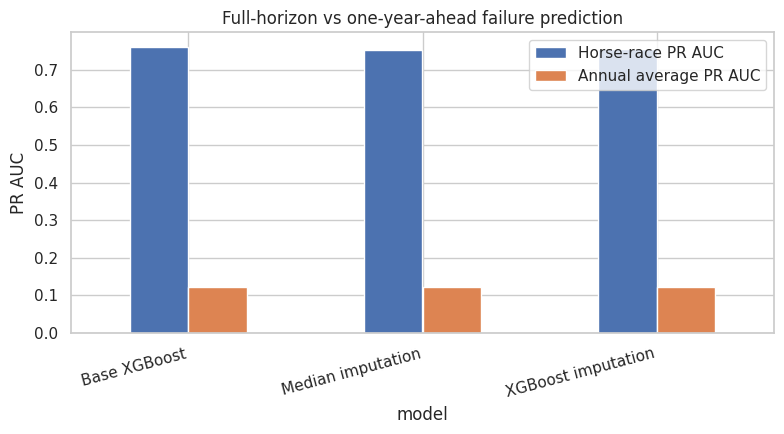

In [17]:
# Compare the full-horizon horse race with the average one-year-ahead PR AUC
# for the same three missing-data strategies.
horse_pr = metrics.set_index("model")["PR_AUC"].rename("Horse-race PR AUC")
annual_pr = yearly_metrics_all.groupby("model")["PR_AUC"].mean().rename("Annual average PR AUC")
comparison = pd.concat([horse_pr, annual_pr], axis=1).dropna()

display(comparison.style.format("{:.3f}"))

comparison.plot(kind="bar", figsize=(8, 4.5))
plt.ylabel("PR AUC")
plt.title("Full-horizon vs one-year-ahead failure prediction")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 9. Defining zombie firms

The R code's encoding is kept:

- category `1`: top risk decile;
- category `2`: risk between the 8th and 9th decile;
- category `0`: risk below the 8th decile.

A firm is a zombie in year `t` if it falls in category `1` in `t`, `t-1`, and `t-2`.

Why a decile-based, multi-year threshold rather than a fixed probability cutoff? The underlying intuition: a viable firm doesn't easily slide into financial distress, but once it does, recovery is hard. So the threshold should reflect genuinely difficult situations, not an arbitrary round number. The balanced-accuracy-optimal cutoff used earlier in this notebook (`best_bacc_threshold`) follows the same logic in the horse-race exercise: BACC is a convex combination of the true positive and true negative rates, so optimizing it balances the cost of missing real failures against the cost of false alarms, rather than just maximizing raw accuracy (which a 5-8% failure rate would let a trivial "never predict failure" model win).


Zombie share by model:


model,Base XGBoost,Median imputation,XGBoost imputation
year,,,
2011,1.58%,1.66%,1.58%
2012,1.86%,1.91%,1.83%
2013,2.16%,2.15%,2.11%
2014,2.25%,2.22%,2.20%
2015,2.61%,2.48%,2.54%
2016,2.81%,2.74%,2.69%
2017,1.83%,1.82%,1.80%


Zombie-firm count by model:


model,Base XGBoost,Median imputation,XGBoost imputation
year,,,
2011,2665,2797,2661
2012,3141,3234,3092
2013,3645,3631,3562
2014,3796,3753,3708
2015,4407,4196,4287
2016,4755,4635,4549
2017,3094,3072,3040


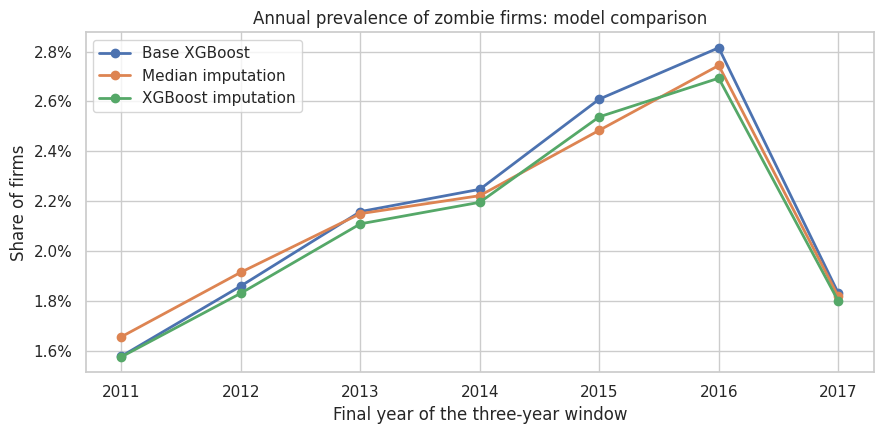

Model used in downstream descriptive sections: Base XGBoost


In [18]:
risk_years = [year + 1 for year in YEARS]
annual_zombie_list = []

# Apply the same three-year persistence definition to each model's annual risk categories.
for model_name, risk_model in risk_results.items():
    for end_year in risk_years[2:]:
        cats = [
            f"cat_{country_tag}_{end_year - 2}",
            f"cat_{country_tag}_{end_year - 1}",
            f"cat_{country_tag}_{end_year}"
        ]
        if not all(c in risk_model.columns for c in cats):
            continue

        risk_model[f"zombie_{country_tag}_{end_year}_{end_year - 2}"] = (
            risk_model[cats].eq(1).all(axis=1).astype(int)
        )

    model_zombie_cols = [
        c for c in risk_model.columns
        if c.startswith(f"zombie_{country_tag}_")
    ]

    annual_zombie_list.append(pd.DataFrame({
        "year": [int(c.split("_")[2]) for c in model_zombie_cols],
        "zombie_share": [risk_model[c].mean() for c in model_zombie_cols],
        "zombie_firms": [int(risk_model[c].sum()) for c in model_zombie_cols],
        "model": model_name
    }))

annual_zombie_all = pd.concat(annual_zombie_list, ignore_index=True).sort_values(["year", "model"])

# Table 1: share of firms classified as zombies.
zombie_share_table = annual_zombie_all.pivot(
    index="year",
    columns="model",
    values="zombie_share"
).sort_index()
print("Zombie share by model:")
display(zombie_share_table.style.format("{:.2%}"))

# Table 2: number of firms classified as zombies.
zombie_count_table = annual_zombie_all.pivot(
    index="year",
    columns="model",
    values="zombie_firms"
).sort_index()
print("Zombie-firm count by model:")
display(zombie_count_table)

# One easy-to-read plot: same zombie definition, three alternative missing-data strategies.
plt.figure(figsize=(9, 4.5))
for model_name, group in annual_zombie_all.groupby("model"):
    group = group.sort_values("year")
    plt.plot(
        group["year"],
        group["zombie_share"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
plt.xlabel("Final year of the three-year window")
plt.ylabel("Share of firms")
plt.title("Annual prevalence of zombie firms: model comparison")
plt.legend()
plt.tight_layout()
plt.show()

# Preserve the rest of the original notebook: downstream sections use the strategy
# that performed best in the section-6 cross-sectional horse race by PR AUC.
selected_model_name = metrics.loc[metrics["PR_AUC"].idxmax(), "model"]
print("Model used in downstream descriptive sections:", selected_model_name)

risk = risk_results[selected_model_name]
yearly_metrics = yearly_metrics_all.loc[
    yearly_metrics_all["model"].eq(selected_model_name)
].copy()
annual_zombie = annual_zombie_all.loc[
    annual_zombie_all["model"].eq(selected_model_name)
].copy()
zombie_cols = [c for c in risk.columns if c.startswith(f"zombie_{country_tag}_")]


to,0.000000,1.000000,2.000000
from,,,
0.000000,90.4%,3.8%,5.8%
1.000000,25.5%,51.4%,23.2%
2.000000,47.0%,23.7%,29.3%


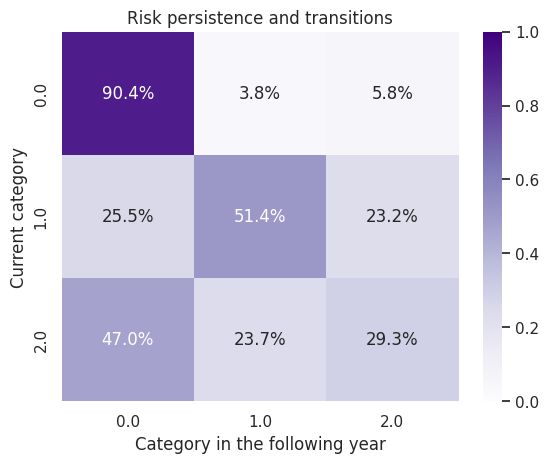

In [19]:
# How often does a firm move between risk categories from one year to the next?
# A crosstab normalized by row ("index") gives, for each starting category, the
# distribution of where firms end up the following year.
transitions = []
for y0, y1 in zip(risk_years[:-1], risk_years[1:]):
    c0, c1 = f"cat_{country_tag}_{y0}", f"cat_{country_tag}_{y1}"
    if c0 not in risk.columns or c1 not in risk.columns:
        continue  # one of the two years was skipped (single-class target)
    temp = risk[[c0, c1]].dropna().rename(columns={c0: "from", c1: "to"})
    temp["period"] = f"{y0}-{y1}"
    transitions.append(temp)
transition_data = pd.concat(transitions, ignore_index=True)
transition_matrix = pd.crosstab(transition_data["from"], transition_data["to"], normalize="index")
display(transition_matrix.style.format("{:.1%}"))
sns.heatmap(transition_matrix, annot=True, fmt=".1%", cmap="Purples", vmin=0, vmax=1)
plt.xlabel("Category in the following year")
plt.ylabel("Current category")
plt.title("Risk persistence and transitions")
plt.show()


## 10. Productivity, size, and geography

The following comparisons are descriptive. Replicating the slides' inferential estimates requires regressions with region and sector fixed effects and clustered errors.


In [20]:
# We add to the loaded data only the useful variables that weren't already among the predictors.
# labour_product is excluded from the main R code due to high missingness, but is useful here as a descriptive outcome.
extra_cols = [f"labour_product_{year}" for year in YEARS]
missing_extra = [c for c in extra_cols if c not in wide.columns]
if missing_extra:
    extra = pd.read_csv(WIDE_FILE, usecols=["id"] + missing_extra)
    wide = wide.merge(extra, on="id", how="left", validate="one_to_one")

characteristics = []
for end_year in risk_years[2:]:
    zcol = f"zombie_{country_tag}_{end_year}_{end_year - 2}"
    if zcol not in risk.columns:
        continue  # three-year window unavailable for one or more skipped years
    feature_year = end_year - 1
    for label, col in {
        "TFP": year_col("tfp_acf", feature_year),
        "Labour productivity": f"labour_product_{feature_year}",
        "Employees": year_col("employees", feature_year),
        "Revenue": year_col("revenue", feature_year),
        "Total assets": year_col("total_assets", feature_year)
    }.items():
        temp = pd.DataFrame({"zombie": risk[zcol], "value": wide[col]})
        summary = temp.groupby("zombie")["value"].agg(["count", "mean", "median"]).reset_index()
        summary["measure"] = label
        summary["year"] = end_year
        characteristics.append(summary)

characteristics = pd.concat(characteristics, ignore_index=True)
display(characteristics.head(30))


,zombie,count,mean,median,measure,year
0,0,45785,6.325513e+00,6.063922e+00,TFP,2011
1,1,546,5.026695e+00,4.873522e+00,TFP,2011
2,0,44828,6.211362e+04,4.819533e+04,Labour productivity,2011
3,1,534,7.120338e+03,2.003840e+04,Labour productivity,2011
4,0,46272,5.364525e+01,1.200000e+01,Employees,2011
5,1,627,7.862839e+00,4.000000e+00,Employees,2011
6,0,99450,8.471705e+06,1.048274e+06,Revenue,2011
7,1,2586,3.157570e+05,1.145340e+05,Revenue,2011
8,0,99780,9.249747e+06,1.125089e+06,Total assets,2011
9,1,2661,9.073866e+05,4.054050e+05,Total assets,2011


,region,firms,zombie_share
10,Molise,575,3.13%
6,Lazio,10529,2.95%
1,Basilicata,1029,2.82%
12,Puglia,7908,2.76%
7,Liguria,2450,2.57%
13,Sardegna,2180,2.43%
2,Calabria,2489,2.37%
14,Sicilia,6512,2.35%
0,Abruzzo,3768,2.31%
17,Umbria,2572,2.18%


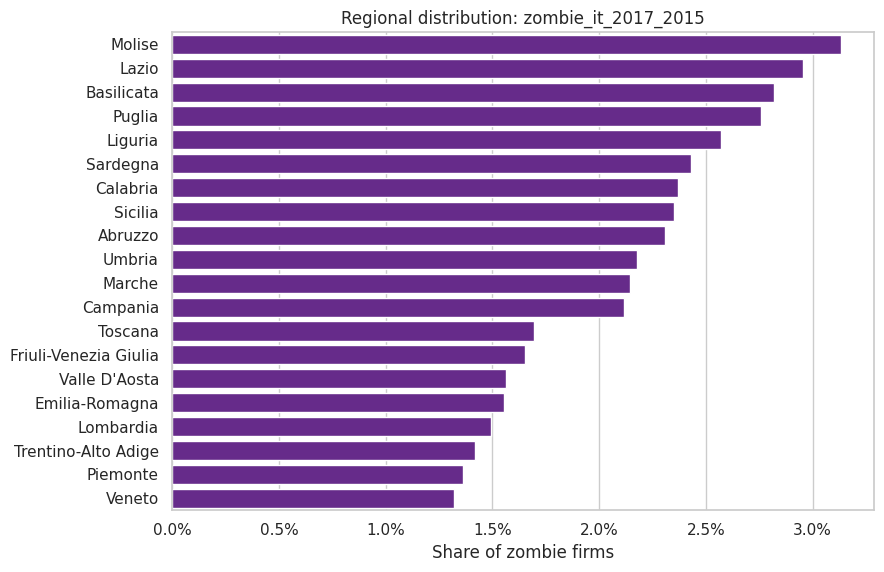

In [21]:
latest_zombie_col = zombie_cols[-1]  # most recent year for which a zombie flag exists
regional = (
    risk.groupby("region", dropna=False)
    .agg(firms=("id", "nunique"), zombie_share=(latest_zombie_col, "mean"))
    .reset_index().sort_values("zombie_share", ascending=False)
)
display(regional.style.format({"zombie_share": "{:.2%}"}))
plt.figure(figsize=(9, max(5, 0.28 * len(regional))))
sns.barplot(data=regional, y="region", x="zombie_share", color="#6A1B9A")
plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
plt.xlabel("Share of zombie firms")
plt.ylabel("")
plt.title(f"Regional distribution: {latest_zombie_col}")
plt.tight_layout()
plt.show()


## 11. Recommended robustness checks

Before using the results in the final slides:

1. run with `QUICK_MODE=False` and five folds;
2. compare XGBoost with BART-MIA in a dedicated R runtime;
3. check probability calibration by year;
4. compare thresholds at the 90th, 85th, and 95th percentile;
5. try persistence windows of two, three, and four years;
6. repeat the analyses by sector and macro-area;
7. document every filter against the shapes printed above for the selected country (for `IT`: 304,869 records in the lagged file and 168,919 firms in the curated wide file; for `FR`/`PT`/`ES` the shapes are smaller and missingness higher, since they are extracted from the raw multi-country panel);
8. interpret SHAP as explaining the predictions, not as a causal effect.


## 12. Exporting the results


In [22]:
# Everything computed above, saved so it can be reused without rerunning the notebook.
metrics.to_csv(OUTPUT_DIR / "horse_race_metrics.csv", index=False)
missing_table.to_csv(OUTPUT_DIR / "missingness_association.csv", index=False)
shap_importance.to_csv(OUTPUT_DIR / "shap_importance.csv", index=False)
group_shap.to_csv(OUTPUT_DIR / "shap_groups.csv", index=False)

yearly_metrics_all.to_csv(OUTPUT_DIR / "yearly_model_metrics_all_strategies.csv", index=False)
annual_zombie_all.to_csv(OUTPUT_DIR / "annual_zombie_prevalence_all_strategies.csv", index=False)

# Selected-best-strategy outputs, kept under the original filenames for compatibility.
yearly_metrics.to_csv(OUTPUT_DIR / "yearly_model_metrics.csv", index=False)
annual_zombie.to_csv(OUTPUT_DIR / "annual_zombie_prevalence.csv", index=False)
transition_matrix.to_csv(OUTPUT_DIR / "risk_transition_matrix.csv")
risk.to_parquet(OUTPUT_DIR / "firm_risk_and_zombie_indicators.parquet", index=False)
characteristics.to_csv(OUTPUT_DIR / "zombie_characteristics.csv", index=False)
regional.to_csv(OUTPUT_DIR / "regional_zombie_prevalence.csv", index=False)

print("Files created:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path)


Files created:
- /content/zombie_outputs/annual_zombie_prevalence.csv
- /content/zombie_outputs/annual_zombie_prevalence_all_strategies.csv
- /content/zombie_outputs/firm_risk_and_zombie_indicators.parquet
- /content/zombie_outputs/horse_race_metrics.csv
- /content/zombie_outputs/missingness_association.csv
- /content/zombie_outputs/regional_zombie_prevalence.csv
- /content/zombie_outputs/risk_transition_matrix.csv
- /content/zombie_outputs/shap_groups.csv
- /content/zombie_outputs/shap_importance.csv
- /content/zombie_outputs/yearly_model_metrics.csv
- /content/zombie_outputs/yearly_model_metrics_all_strategies.csv
- /content/zombie_outputs/zombie_characteristics.csv


## Key takeaways

- **Machine learning can extract non-trivial signal from a battery of financial indicators *and* their missingness**, successfully separating risk categories after training on past failures.
- **Zombie firms** are defined here as those that stay in the highest risk category (beyond roughly the 9th decile of predicted risk) for at least three consecutive years -- the point beyond which recovery becomes rare in the data.
- In the **post-pandemic environment**, separating firms that can stand on their own from those concealing insolvency behind incomplete disclosures is a first-order policy question, not just a modeling exercise.


## 13. Homework exercise: cross-country generalization

So far every model has been trained and evaluated on the **same** country (`COUNTRY`). A natural question: does a model trained on Italian data also recognize at-risk firms in France, Portugal, or Spain?

Build a *leave-one-country-out* exercise, to be handed in as a comment/discussion (working code is a bonus, not a requirement):

1. Train the "XGBoost missing-aware" model (section 6) on **three** countries pooled together (e.g. IT + PT + ES) — `data_lagged_10_07.csv` already contains all of them, just don't filter the training set by `COUNTRY`.
2. Evaluate it on the fourth country, never seen during training (e.g. FR), using the same metrics (ROC AUC, PR AUC, F1, BACC).
3. Compare this result with the PR AUC obtained in section 6 when training and testing are on the same country.
4. Discuss: does any performance loss reflect differences in accounting standards, sector composition, or data quality/quantity across countries? Section 5.1 (complete-case share by country) is a good starting point for this discussion.


## Methodological provenance

The notebook was built starting from:

- `Slides1-3.tex`, the *Learning and Firm Survival* presentation -- its motivation, missingness taxonomy, model lineage, Shapley formula, and conclusions are now reproduced inline in the relevant sections above, so you shouldn't need to open the slides separately;
- `ml_analysis_lagged.R`, horse race between logit, CART, random forest, BART-MIA, and other models;
- `country_year_italy.R`, annual estimates and risk categories;
- `variables_importance.R`, variable importance;
- `data_lagged_10_07.dta` and `data_italy.dta` (for Italy), plus `zombie_indicator_by_country.dta` (multi-country panel) for the extension to FR/PT/ES.

For teaching purposes, these Stata files were converted to CSV keeping only the columns needed for the analysis:
- `data_lagged_10_07.csv`: all four countries, filtered at runtime based on `COUNTRY`;
- `data_wide_IT.csv`, `data_wide_FR.csv`, `data_wide_PT.csv`, `data_wide_ES.csv`: one file per country, so each student only downloads the data they need.

Benchmark reported in the material (computed on IT): the missing-aware model reaches about 0.97 ROC AUC and 0.75-0.76 PR AUC. The zombie definition requires staying in the top risk decile for at least three consecutive years.


### References cited in the notes above

- Caballero, R. J., Hoshi, T., & Kashyap, A. K. (2008). Zombie lending and depressed restructuring in Japan. *American Economic Review*.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data*.
- McGowan, M. A., Andrews, D., & Millot, V. (2018). The walking dead: Zombie firms and productivity performance in OECD countries. *Economic Policy*.
- Kapelner, A., & Bleich, J. (2015). Prediction with missing data via Bayesian additive regression trees. *Canadian Journal of Statistics*.
- Bargagli-Stoffi, F. J., Niederreiter, J., & Riccaboni, M. (2021). Supervised learning for the prediction of firm dynamics. In *Data Science for Economics and Finance*.
